In [56]:
ls /data0/medetec_wound/

abdominalwounds/        Haemangiomas/         Pilonidalsinuswounds/
burnsandscalds/         Malignantwounds/      pressureulcers/
diabeticfootulcers/     Meningitiswounds/     Toesinfectedandnecrotic/
epidermolysisbullosa/   Miscellaneouswounds/  venousandarterialulcers/
extravasationinjuries/  orthopaedicwounds/


In [9]:
pip install requests beautifulsoup4

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import os
import requests
from bs4 import BeautifulSoup
import time
import cv2
import matplotlib.pyplot as plt
import os
from glob import glob

In [34]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/abdominal-wounds/index.html"
SAVE_DIR = "/data0/medetec_wound/abdominalwounds"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")


Downloaded: /data0/medetec_wound/abdominalwounds/introslide.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-2.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-1.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-3.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-4.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-jpg256.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-5.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-6.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-7.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-8.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgical-wound-11.jpg
Downloaded: /data0/medetec_wound/abdominalwounds/dehisced-surgi

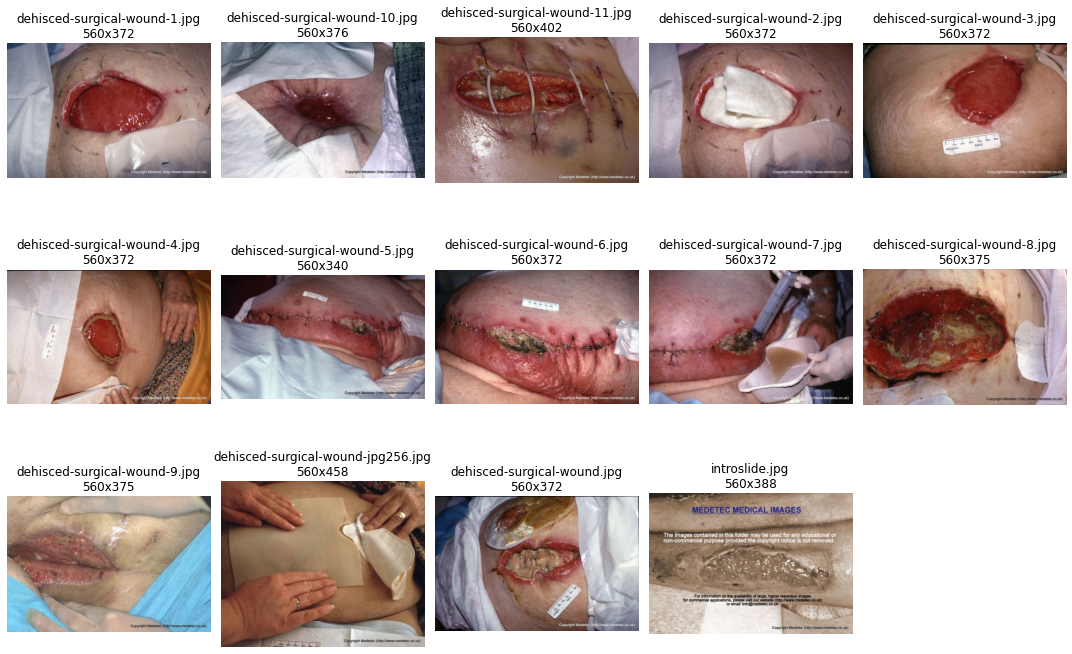

In [38]:
image_folder = "/data0/medetec_wound/abdominalwounds"

image_files = sorted(glob(os.path.join(image_folder, "*.jpg")))
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(image_files):
    if i >= len(axes):
        break

    img = cv2.imread(img_path) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width, channels = img.shape
    resolution = f"{width}x{height}"
    axes[i].imshow(img)
    axes[i].set_title(f"{os.path.basename(img_path)}\n{resolution}")
    axes[i].axis("off")
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [39]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/burns/index.html"
SAVE_DIR = "/data0/medetec_wound/burnsandscalds"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")


Downloaded: /data0/medetec_wound/burnsandscalds/copy-of-introslide.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case1-burns-to-hand-and-arm-1.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case1-burns-to-hand-and-arm.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case2-burn-to-arm-1.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case2-burn-to-arm-2.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case2-burn-to-arm-3.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case2-burn-to-arm-4.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case2-burn-to-arm-5.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case2-burn-to-arm-6.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case2-burns-to-arm-7.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case3-burn-to-head-showing-healing-0.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case3-burn-to-head-showing-healing-1.jpg
Downloaded: /data0/medetec_wound/burnsandscalds/case3-burn-to-head-showing-healing-2

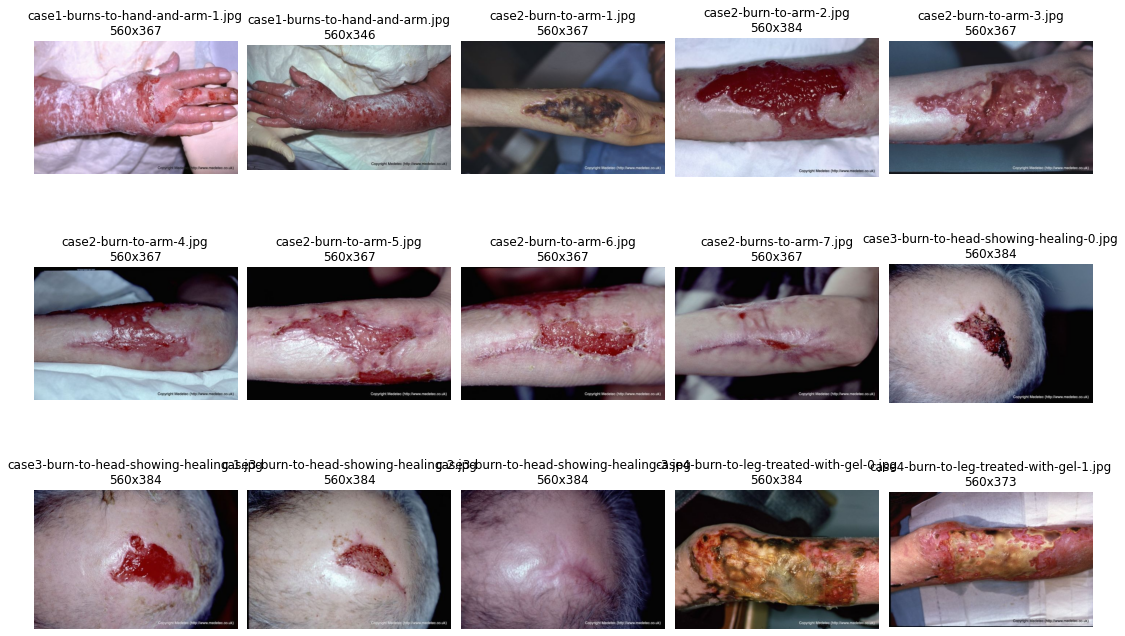

In [40]:
image_folder = "/data0/medetec_wound/burnsandscalds"

image_files = sorted(glob(os.path.join(image_folder, "*.jpg")))
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(image_files):
    if i >= len(axes):
        break

    img = cv2.imread(img_path) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width, channels = img.shape
    resolution = f"{width}x{height}"
    axes[i].imshow(img)
    axes[i].set_title(f"{os.path.basename(img_path)}\n{resolution}")
    axes[i].axis("off")
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [41]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/epidermolysis-bullosa/index.html"
SAVE_DIR = "/data0/medetec_wound/epidermolysisbullosa/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")


Downloaded: /data0/medetec_wound/epidermolysisbullosa/introslide.jpg
Downloaded: /data0/medetec_wound/epidermolysisbullosa/epidermolysis-bullosa-0002.jpg
Downloaded: /data0/medetec_wound/epidermolysisbullosa/epidermolysis-bullosa-0003.jpg
Downloaded: /data0/medetec_wound/epidermolysisbullosa/epidermolysis-bullosa-0006.jpg
Downloaded: /data0/medetec_wound/epidermolysisbullosa/epidermolysis-bullosa-0004.jpg
Downloaded: /data0/medetec_wound/epidermolysisbullosa/epidermolysis-bullosa-0005.jpg
All images downloaded successfully!


In [42]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/extravasation-wound-images/index.html"
SAVE_DIR = "/data0/medetec_wound/extravasationinjuries/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/extravasationinjuries/introslide.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-a-001.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-a-002.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-a-003.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-a-004.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-a-005.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-a-006.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-a-007.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-b-001.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-b-002.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-b-003.jpg
Downloaded: /data0/medetec_wound/extravasationinjuries/extravasation-wound-b-004

In [43]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/foot-ulcers/index.html"
SAVE_DIR = "/data0/medetec_wound/diabeticfootulcers/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/diabeticfootulcers/introslide.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer-0002.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer-0001.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer1-1.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer1-8.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer1-2.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer1-3.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer1-4.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer1-5.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer1-6.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer-2-1.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer-2-2.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer-2-3.jpg
Downloaded: /data0/medetec_wound/diabeticfootulcers/foot-ulcer-2-4.jpg
Downloaded: /da

In [44]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/haemangioma/index.html"
SAVE_DIR = "/data0/medetec_wound/Haemangiomas/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/Haemangiomas/introslide.jpg
Downloaded: /data0/medetec_wound/Haemangiomas/haemangioma-1-0.jpg
Downloaded: /data0/medetec_wound/Haemangiomas/haemangioma-1-1.jpg
Downloaded: /data0/medetec_wound/Haemangiomas/haemangioma-1-2.jpg
Downloaded: /data0/medetec_wound/Haemangiomas/haemangioma-1-3.jpg
Downloaded: /data0/medetec_wound/Haemangiomas/haemangioma-1-4.jpg
Downloaded: /data0/medetec_wound/Haemangiomas/haemangioma-2.jpg
All images downloaded successfully!


In [45]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/leg-ulcer-images/index.html"
SAVE_DIR = "/data0/medetec_wound/venousandarterialulcers/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/venousandarterialulcers/introslide.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0057.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0001.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0002.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0003.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0005.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0006.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0007.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0004.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0009.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0010.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0011.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0012.jpg
Down

In [46]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/leg-ulcer-images-2/index.html"
SAVE_DIR = "/data0/medetec_wound/venousandarterialulcers/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/venousandarterialulcers/introslide.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/sloughy-leg-ulcer-0101.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/sloughy-leg-ulcer-0101-1.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/ischaemic-leg-ulcer-with-tendon-visible.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/ischaemic-leg-ulcer-with-tendon-visible-1.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-with-punched-out-apperance.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-with-punched-out-apperance-1.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcer-healing-well-0107.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/healing-venous-leg-ulcers-with-skin-staining.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/sloughy-leg-ulcer-0109.jpg
Downloaded: /data0/medetec_wound/venousandarterialulcers/leg-ulcers-0110.jp

In [47]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/malignant-wound-images/index.html"
SAVE_DIR = "/data0/medetec_wound/Malignantwounds/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/Malignantwounds/mal-0004.jpg
Downloaded: /data0/medetec_wound/Malignantwounds/mal-0001.jpg
Downloaded: /data0/medetec_wound/Malignantwounds/mal-0005.jpg
Downloaded: /data0/medetec_wound/Malignantwounds/mal-0007.jpg
Downloaded: /data0/medetec_wound/Malignantwounds/mal-0006.jpg
Downloaded: /data0/medetec_wound/Malignantwounds/mal-0014.jpg
Downloaded: /data0/medetec_wound/Malignantwounds/mal-0002.jpg
Downloaded: /data0/medetec_wound/Malignantwounds/mal-0003.jpg
Downloaded: /data0/medetec_wound/Malignantwounds/mal-008.jpg
All images downloaded successfully!


In [48]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/meningitis/index.html"
SAVE_DIR = "/data0/medetec_wound/Meningitiswounds/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/Meningitiswounds/introslide.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-elbow-1.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-elbow-2.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-elbow-3.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-elbow-4.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-elbow-5.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-elbow-6.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-feet-1.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-feet-2.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-feet-3.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-feet-4.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis-case-1-feet-5.jpg
Downloaded: /data0/medetec_wound/Meningitiswounds/meningitis

In [49]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/orthopaedic%20wounds/index.html"
SAVE_DIR = "/data0/medetec_wound/orthopaedicwounds/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/orthopaedicwounds/introslide.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-1.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-2.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-3.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-4.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-5.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-6.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-7.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-8.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-9.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-10.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-11.jpg
Downloaded: /data0/medetec_wound/orthopaedicwounds/orthopaedic-wound-1-12.jpg
Downloa

In [50]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/miscellaneous/index.html"
SAVE_DIR = "/data0/medetec_wound/Miscellaneouswounds/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/Miscellaneouswounds/introslide.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/epithelialising-wound.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/alginate-dressing-being-removed.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/removal-of-kaltostat.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/epithelialising-wound2.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/debrisan-beads-in-foot-wound.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/fibres-from-paraffn-gauze-in-wound.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/accupuncture-for-ulcer-treatment.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/extravasation-wound.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/probing-a-wound-with-a-gloved-fiinger.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/problem-of-exudate-management.jpg
Downloaded: /data0/medetec_wound/Miscellaneouswounds/maceration-of-periwound-sk

In [51]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/pressure-ulcer-images-a/index.html"
SAVE_DIR = "/data0/medetec_wound/pressureulcers/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/pressureulcers/introslide.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-neck-001.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-neck-0002.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-neck-003.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-neck-004.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-head-006.jpg
Downloaded: /data0/medetec_wound/pressureulcers/healing0037.jpg
Downloaded: /data0/medetec_wound/pressureulcers/healing0038.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-foot-0003.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-foot-0018.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-foot-0020.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-foot-0022.jpg
Downloaded: /data0/medetec_wound/pressureulcers/pressure-ulcer-on-foot-0023.jpg
Downloaded: /

In [52]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/pressure-ulcer-images-b/index.html"
SAVE_DIR = "/data0/medetec_wound/pressureulcers/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/pressureulcers/introslide.jpg
Downloaded: /data0/medetec_wound/pressureulcers/sloughy-pressure-ulcer-0019.jpg
Downloaded: /data0/medetec_wound/pressureulcers/sloughy-presure-ulcer-0020.jpg
Downloaded: /data0/medetec_wound/pressureulcers/sloughy-pressure-ulcer-0022.jpg
Downloaded: /data0/medetec_wound/pressureulcers/superficial-pressure-ulcer0003.jpg
Downloaded: /data0/medetec_wound/pressureulcers/sloughy-pressure-ulcer-0024.jpg
Downloaded: /data0/medetec_wound/pressureulcers/superficial-pressure-ulcer0005.jpg
Downloaded: /data0/medetec_wound/pressureulcers/sloughy-pressure-ulcer-0025.jpg
Downloaded: /data0/medetec_wound/pressureulcers/superficial-pressure-ulcer0002.jpg
Downloaded: /data0/medetec_wound/pressureulcers/sloughy-pressure-ulcer-0026.jpg
Downloaded: /data0/medetec_wound/pressureulcers/superficial-pressure-ulcer0008.jpg
Downloaded: /data0/medetec_wound/pressureulcers/sloughy-pressure-ulcer-0027.jpg
Downloaded: /data0/medetec_wound/pressureulcer

In [53]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/pilonidal-sinus/index.html"
SAVE_DIR = "/data0/medetec_wound/Pilonidalsinuswounds/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/Pilonidalsinuswounds/introslide.jpg
Downloaded: /data0/medetec_wound/Pilonidalsinuswounds/pilonidal-sinus0005.jpg
Downloaded: /data0/medetec_wound/Pilonidalsinuswounds/pilonidal-sinus0001.jpg
Downloaded: /data0/medetec_wound/Pilonidalsinuswounds/pilonidal-sinus0002.jpg
All images downloaded successfully!


In [54]:
BASE_URL = "https://www.medetec.co.uk/slide%20scans/toes/index.html"
SAVE_DIR = "/data0/medetec_wound/Toesinfectedandnecrotic/"

def get_full_image_links(base_url):
    response = requests.get(base_url)
    if response.status_code != 200:
        print("Failed to retrieve page")
        return []

    soup = BeautifulSoup(response.text, "html.parser")
    image_links = []
    for a_tag in soup.find_all("a", href=True):
        img_tag = a_tag.find("img")
        if img_tag:
            full_image_page = a_tag["href"]
            image_links.append(full_image_page)

    return image_links

def get_actual_image_url(image_page_url):
    full_url = requests.compat.urljoin(BASE_URL, image_page_url)
    response = requests.get(full_url)
    if response.status_code != 200:
        print(f"Failed to retrieve image page: {full_url}")
        return None

    soup = BeautifulSoup(response.text, "html.parser")
    
    img_tag = soup.find("img")
    if img_tag and "src" in img_tag.attrs:
        full_image_url = requests.compat.urljoin(full_url, img_tag["src"])
        return full_image_url
    
    return None

def download_image(image_url, save_dir):
    image_name = image_url.split("/")[-1]
    image_path = os.path.join(save_dir, image_name)

    response = requests.get(image_url, stream=True)
    if response.status_code == 200:
        with open(image_path, "wb") as file:
            for chunk in response.iter_content(1024):
                file.write(chunk)
        print(f"Downloaded: {image_path}")
    else:
        print(f"Failed to download: {image_url}")
image_pages = get_full_image_links(BASE_URL)

for img_page in image_pages:
    actual_image_url = get_actual_image_url(img_page)
    if actual_image_url:
        download_image(actual_image_url, SAVE_DIR)
    
    time.sleep(1)

print("All images downloaded successfully!")

Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0043.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0042.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-00431.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0004.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0006.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0008.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0010.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0013.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0014.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0015.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0016.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0018.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0019.jpg
Downloaded: /data0/medetec_wound/Toesinfectedandnecrotic/toes-0020.jpg
Downl

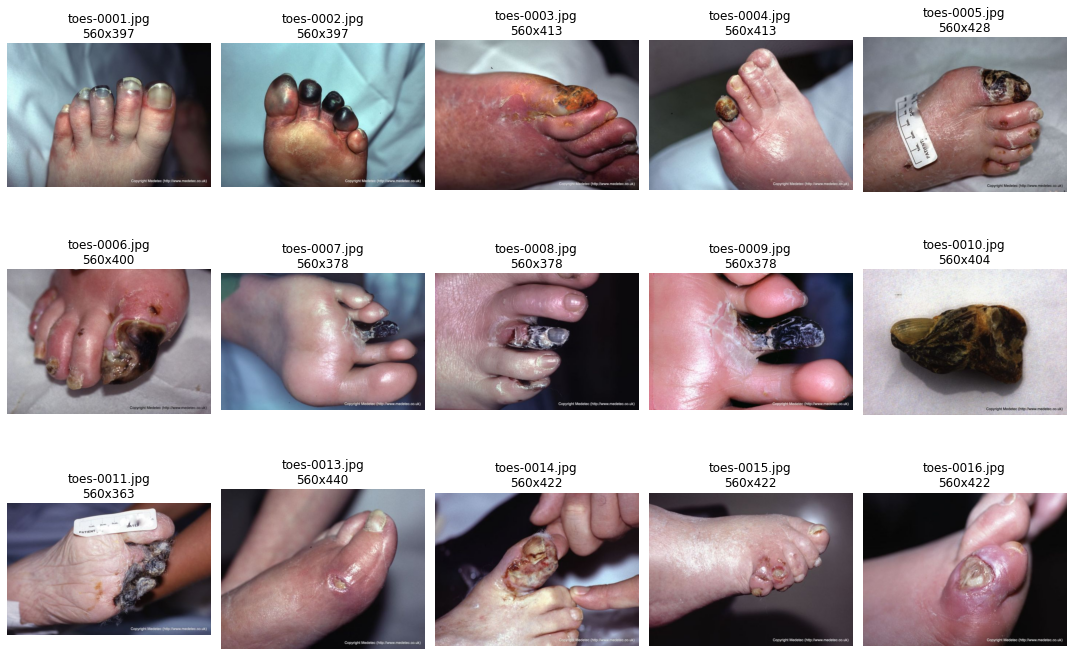

In [55]:
image_folder = "/data0/medetec_wound/Toesinfectedandnecrotic"

image_files = sorted(glob(os.path.join(image_folder, "*.jpg")))
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(image_files):
    if i >= len(axes):
        break

    img = cv2.imread(img_path) 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width, channels = img.shape
    resolution = f"{width}x{height}"
    axes[i].imshow(img)
    axes[i].set_title(f"{os.path.basename(img_path)}\n{resolution}")
    axes[i].axis("off")
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [59]:
ls /data0/medetec_wound/

abdominalwounds/        Haemangiomas/         Pilonidalsinuswounds/
burnsandscalds/         Malignantwounds/      pressureulcers/
diabeticfootulcers/     Meningitiswounds/     Toesinfectedandnecrotic/
epidermolysisbullosa/   Miscellaneouswounds/  venousandarterialulcers/
extravasationinjuries/  orthopaedicwounds/


In [72]:
ls /data0/medetec_wound/venousandarterialulcers/

case-1-2-showing-extent-of-oedema-2.jpg
case-1-3-inadequately-bandaged.jpg
case-1-4-dressed-with-compression-bandage.jpg
case-1-5-oedema-starting-to-reduce-1-oedema-starting-to-reduce.jpg
case-1-skin-reaction-to-soframycin-tulle-.jpg
gravitational-ulcers.jpg
healingn-leg-ulcers-0114.jpg
healing-venous-leg-ulcers-with-skin-staining.jpg
introslide.jpg
ischaemic-leg-ulcer-with-tendon-visible-1.jpg
ischaemic-leg-ulcer-with-tendon-visible.jpg
leg-ulcer-case-2-10.jpg
leg-ulcer-case-2-11.jpg
leg-ulcer-case-2-12.jpg
leg-ulcer-case-2-13.jpg
leg-ulcer-case-2-14.jpg
leg-ulcer-case-2-15.jpg
leg-ulcer-case-2-1.jpg
leg-ulcer-case-2-2.jpg
leg-ulcer-case-2-3.jpg
leg-ulcer-case-2-4.jpg
leg-ulcer-case-2-5.jpg
leg-ulcer-case-2-6.jpg
leg-ulcer-case-2-7.jpg
leg-ulcer-case-2-8.jpg
leg-ulcer-case-2-9.jpg
leg-ulcer-case-2.jpg
leg-ulcer-case-3-10.jpg
leg-ulcer-case-3-11.jpg
leg-ulcer-case-3-1.jpg
leg-ulcer-case-3-2.jpg
leg-ulcer-case-3-3.jpg
leg-ulcer-case-3-4.jpg
leg-ulcer-case-3-5.jpg
leg-ulcer-case-3-6.jpg
